Rough vol Calibration
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Jackels import impliedVolJaeckelRational
%matplotlib inline
from scipy.interpolate import interp1d
import pandas as pd
import scipy.signal as signal
import scipy.integrate as integrate
import scipy.special as special
from scipy.optimize import minimize
from scipy.optimize import bisect
from scipy.stats import norm

## Black-Scholes

Black-Scholes with no rate and no dividends

In [2]:
# Black Scholes formula
def BlackScholes(callPutFlag, S0, K, sigma, T):
    def d1(S0, K, sigma, T):
        return (np.log(S0/K) + .5*sigma**2*T) / (sigma*np.sqrt(T))

    def d2(S0, K, sigma, T):
        return (np.log(S0 / K) - .5*sigma**2* T) / (sigma*np.sqrt(T))

    if callPutFlag == "C":
        return S0 * norm.cdf(d1(S0,K,sigma,T)) - K*np.exp(-r*T) * norm.cdf(d2(S0,K,sigma,T))
    else:
        return K*norm.cdf(-d2(S0, K, sigma, T)) - S0*norm.cdf(-d1(S0, K, sigma, T))

## Rough Bergomi

In [3]:
def rBergomi_hybrid(grid_points, nbPaths, kappa, S0, T, params):
    """
    grid_points: number of points in the simulation grid
    kappa: parameter (equal to 1 or 2)
    nbPaths: number of paths to simulate
    S0: Stock price at time 0
    T: time horizon
    params = H, xi0, nu, rho
    H: Hurst parameter
    xi0: initial forward variance curve
    nu: volatility model parameter
    rho:BM correlation parameter
    """

    H, xi0, nu, rho = params
    grid = np.linspace(0,T,grid_points)
    alpha = H-0.5
    n = grid[1]
    #compute optimal b_k=(b^*_k)^(H-1/2) for k>kappa+1
    aux = grid_points-kappa-1
    k1 = np.arange(kappa)+1
    k2 = np.arange(aux)+kappa+1

    #create the correlated Gaussian processes
    VAR1 = (np.power(k1,2*H)-np.power(k1-1,2*H))*np.power(n,2*H)/(2.0*H)
    VAR2 = n
    COV = (np.power(k1,alpha+1)-np.power(k1-1,alpha+1))*np.power(n,alpha+1)/(alpha+1)
    #create mean vector
    mean = np.zeros(kappa+1)
    #create covariance matrix
    cov = np.diag(np.append(VAR1,VAR2)) 
    cov[0:kappa,kappa] = COV
    cov[kappa,0:kappa] = COV
    
    if kappa>1:
        COV1 = np.power(n,2.0*alpha+1)/(alpha+1)*special.hyp2f1(1,2.0*(alpha+1),alpha+2,-1.0)*np.power(2.0,alpha+1)
        cov[0,1] = COV1
        cov[1,0] = COV1
    
    #Create optimal b*_k
    b_k = np.power(n,alpha)*((np.power(k2,alpha+1)-np.power(k2-1,alpha+1))/(alpha+1))
    a_k = np.array([np.append(np.zeros(kappa),b_k)])
    
    #Create the correlated random samples carefully to be consistent with parallel computing
    size = (grid_points-1)*nbPaths
    local_state = np.random.RandomState(None)
    RAND = local_state.multivariate_normal(mean, cov, size)
    
    RAND1 = RAND[:,0:kappa]
    
    #Compute also the first kappa samples of  correlated BM W, which drives the stock price
    W = np.zeros([nbPaths,grid_points-1])
    rho_comp = np.power(1-np.power(rho,2),0.5)
    index = np.arange(nbPaths)*(grid_points-1)
    local_state = np.random.RandomState(None)
    for i in range(kappa):
        W[:,i] = rho*RAND[index+i,i]*np.power(VAR1[i]/n,-0.5) + rho_comp*np.power(n,0.5)*local_state.normal(loc=0., scale=1., size=nbPaths)
    
    #If kappa>1 modify compute X1 first
    if kappa>1:
        RAND1[1:size,1] = RAND1[0:size-1,1]
        RAND1[np.arange(nbPaths)*(grid_points-1),1] = 0
        RAND1 = np.sum(RAND1,axis=1)
        
    RAND1 = RAND1.reshape((nbPaths,grid_points-1))
    
    #Compute X2 using discrete convolution and  FFT
    RAND2 = RAND[:,kappa:kappa+1].reshape((nbPaths,grid_points-1))
    RAND = None
    u = signal.fftconvolve(a_k,RAND2[:,0:grid_points-1-kappa], mode='full') 
    
    #Also generate the correlated BM for the stock price
    local_state = np.random.RandomState(None)
    W[:,kappa:grid_points-1] = rho*RAND2[:,kappa:grid_points-1]+rho_comp*np.power(n,0.5)*local_state.normal(loc=0.0, scale=1.0, size=[nbPaths,grid_points-kappa-1])
    RAND2 = None
    
    #generate X(i/n)=X1(i/n)+X2(i/n)
    path = np.zeros([nbPaths,grid_points])
    
    path[:,1:grid_points] = u[:,0:grid_points-1]+RAND1
    u = None
    RAND1 = None

    C_H = np.power(2*H*special.gamma(3.0/2.0-H)/special.gamma(H+0.5)/special.gamma(2.0-2.0*H),0.5)

    volatility = np.power(xi0,0.5)*np.exp(path*C_H*nu - np.power(nu*C_H,2)*np.power(grid,2*H)/2/H)
    
    path = None
    
    #Once the volatility is simulated we can produce the stock dynamics using forward Euler method
    stock = S0 * np.ones([nbPaths,grid_points])
    
    for i in range(grid_points-1):
        stock[:,i+1] = stock[:,i] + stock[:,i]*volatility[:,i]*W[:,i]
    W = None
    return (volatility,stock)

## Rough Bergomi with frozen H (faster for calibration)

In [4]:
def rBergomi_gen_Matrix(grid_points, nbPaths, kappa, S0, T, H):
    """
    grid_points: number of points in the simulation grid
    kappa: parameter (equal to 1 or 2)
    nbPaths: number of paths to simulate
    S0: Stock price at time 0
    T: time horizon
    H: Hurst parameter
    """

    grid = np.linspace(0,T,grid_points)
    alpha = H-0.5
    n = grid[1]
    #compute optimal b_k=(b^*_k)^(H-1/2) for k>kappa+1
    aux = grid_points-kappa-1
    k1 = np.arange(kappa)+1
    k2 = np.arange(aux)+kappa+1

    #create the correlated Gaussian processes
    VAR1 = (np.power(k1,2*H)-np.power(k1-1,2*H))*np.power(n,2.*H)/(2.*H)
    VAR2 = n
    COV = (np.power(k1,alpha+1)-np.power(k1-1,alpha+1))*np.power(n,alpha+1)/(alpha+1)
    #create mean vector
    mean = np.zeros(kappa+1)
    #create covariance matrix
    cov = np.diag(np.append(VAR1,VAR2)) 
    cov[0:kappa,kappa] = COV
    cov[kappa,0:kappa] = COV
    
    if kappa>1:
        COV1 = np.power(n,2.0*alpha+1)/(alpha+1)*special.hyp2f1(1,2.0*(alpha+1),alpha+2,-1.0)*np.power(2.0,alpha+1)
        cov[0,1] = COV1
        cov[1,0] = COV1
    
    #Create optimal b*_k
    b_k = np.power(n,alpha)*((np.power(k2,alpha+1)-np.power(k2-1,alpha+1))/(alpha+1))
    a_k = np.array([np.append(np.zeros(kappa),b_k)])
    
    #Create the correlated random samples carefully to be consistent with parallel computing
    size = (grid_points-1)*nbPaths
    RAND = np.random.multivariate_normal(mean, cov, size)
    
    RAND1 = RAND[:,0:kappa]
    
    #Compute also the first kappa samples of  correlated BM W, which drives the stock price
    W = np.zeros([nbPaths,grid_points-1])
    index = np.arange(nbPaths)*(grid_points-1)
    gaussianMatrix = np.random.normal(loc=0., scale=1., size=nbPaths)

    #If kappa>1 modify compute X1 first
    if kappa>1:
        RAND1[1:size,1] = RAND1[0:size-1,1]
        RAND1[np.arange(nbPaths)*(grid_points-1),1] = 0
        RAND1 = np.sum(RAND1,axis=1)
        
    RAND1 = RAND1.reshape((nbPaths,grid_points-1))
    
    #Compute X2 using discrete convolution and  FFT
    RAND2 = RAND[:,kappa:kappa+1].reshape((nbPaths,grid_points-1))
    u = signal.fftconvolve(a_k,RAND2[:,0:grid_points-1-kappa], mode='full') 

    gaussianMatrix2 = np.random.normal(loc=0.0, scale=1.0, size=[nbPaths,grid_points-kappa-1])
    
    path = np.zeros([nbPaths,grid_points])
    path[:,1:grid_points] = u[:,0:grid_points-1] + RAND1
    u = None
    RAND1 = None
    stockinit = S0 * np.ones([nbPaths,grid_points])
    
    return index, W, VAR1, RAND, RAND2, size, a_k, b_k, gaussianMatrix, gaussianMatrix2, grid, path, stockinit
    
def rBergomi_hybrid_Fast(grid_points, nbPaths, kappa, S0, T, params_noH, H, importedVal):
    """
    grid_points: number of points in the simulation grid
    kappa: parameter (equal to 1 or 2)
    nbPaths: number of paths to simulate
    S0: Stock price at time 0
    T: time horizon
    params = H, xi0, nu, rho
    H: Hurst parameter
    xi0: initial forward variance curve
    nu: volatility model parameter
    rho:BM correlation parameter
    """
    index, W, VAR1, RAND, RAND2, size, a_k, b_k, gaussianMatrix, gaussianMatrix2, grid, path, stockinit =  importedVal
    
    xi0, nu, rho = params_noH
    alpha = H - 0.5
    n = grid[1]
    #compute optimal b_k=(b^*_k)^(H-1/2) for k>kappa+1
    aux = grid_points-kappa-1
    rho_comp = np.power(1-np.power(rho,2),0.5)
    
    for i in range(kappa):
        W[:,i] = rho*RAND[index+i,i]*np.power(VAR1[i]/n,-0.5) + rho_comp*np.power(n,0.5)*gaussianMatrix
        
    #Also generate the correlated BM for the stock price
    #local_state = np.random.RandomState(None)
    W[:,kappa:grid_points-1] = rho*RAND2[:,kappa:grid_points-1]+rho_comp*np.power(n,0.5)*gaussianMatrix2
    RAND2 = None
    
    #generate X(i/n)=X1(i/n)+X2(i/n)
    
    C_H = np.power(2*H*special.gamma(3.0/2.0-H)/special.gamma(H+0.5)/special.gamma(2.0-2.0*H),0.5)

    volatility = np.power(xi0,0.5)*np.exp(path*C_H*nu - np.power(nu*C_H,2)*np.power(grid,2*H)/2/H)
    
    path = None
    
    #Once the volatility is simulated we can produce the stock dynamics using forward Euler method
    stock = stockinit
    
    for i in range(grid_points-1):
        stock[:,i+1] = stock[:,i] + stock[:,i]*volatility[:,i]*W[:,i]
    W = None
    return (volatility,stock)

In [5]:
def compute_CallPrices_from_ST(strikes, stockpath):
    """
    strikes: array of strikes
    stockpath: matrix of stock paths
    """
    return [np.mean(np.maximum(stockpath[:,-1] - K,0)) for K in strikes]

def rBergomi_callPrices_Fast(strikes, grid_points, nbPaths, kappa, S0, T, paramsnoH, H, importedVal):
    (volpath,stockpath) = rBergomi_hybrid_Fast(grid_points, nbPaths, kappa, S0, T, paramsnoH, H, importedVal)
    return [np.mean(np.maximum(stockpath[:,-1] - K,0)) for K in strikes]

def rBergomi_callPrices(strikes, grid_points, nbPaths, kappa, S0, T, params):
    (volpath,stockpath) = rBergomi_hybrid(grid_points, nbPaths, kappa, S0, T, params)
    return [np.mean(np.maximum(stockpath[:,-1] - K,0)) for K in strikes]

def rBergomi_implied_vol(strikes, grid_points, nbPaths, kappa, S0, T, params):
    (volpath,stockpath) = rBergomi_hybrid(grid_points, nbPaths, kappa, S0, T, params)
    callprices = [np.mean(np.maximum(stockpath[:,-1] - K,0)) for K in strikes]
    return [impliedVolJaeckelRational(S0, K, c, T) for (K,c) in zip(strikes, callprices)]

def rBergomi_implied_from_Calls(strikes, callPrices, S0, T):
    return [impliedVolJaeckelRational(S0, K, c, T) for (K,c) in zip(strikes, callPrices)]

## Numerics

In [6]:
kappa = 2
H = 0.1
xi0, nu, rho = np.power(0.235,2), 0.8, -0.5
params = H, xi0, nu, rho
paramsnoH = xi0, nu, rho
S0, T = 1., 1.

nbStrikes = 10
grid_points = 200
nbPaths = 100000
strikes = np.linspace(S0*np.exp(-0.4), S0*np.exp(0.4), nbStrikes)
log_moneyness = np.log(strikes/S0)

In [10]:
importedVal = rBergomi_gen_Matrix(grid_points, nbPaths, kappa, S0, T, H)

(volpath,stockpath) = rBergomi_hybrid_Fast(grid_points, nbPaths, kappa, S0, T, paramsnoH, H, importedVal)

Call_prices = compute_CallPrices_from_ST(strikes, stockpath)
print("Call prices: ", np.round(Call_prices_Fast, 6))

Call prices:  [0.336001 0.254079 0.179907 0.117191 0.069185 0.037083 0.018396 0.00873
 0.004098 0.001929]


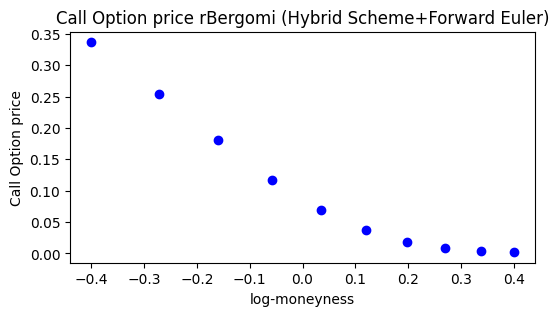

In [16]:
plt.figure(figsize=(6, 3))
plt.plot(log_moneyness,Call_prices, 'bo')
plt.xlabel('log-moneyness')
plt.ylabel('Call Option price')
plt.title('Call Option price rBergomi (Hybrid Scheme+Forward Euler)')
plt.show()

In [17]:
ivs = rBergomi_implied_from_Calls(strikes, Call_prices, S0, T)

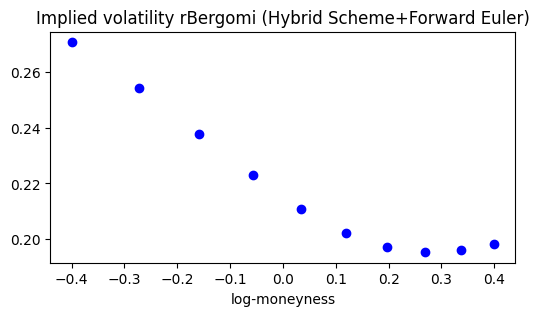

In [19]:
plt.figure(figsize=(6, 3))
plt.plot(log_moneyness, ivs, 'bo')
plt.xlabel('log-moneyness')
plt.title('Implied volatility rBergomi (Hybrid Scheme+Forward Euler)')
plt.show()

## Import option price data

In [21]:
S0 = 179.83

data = pd.read_csv('dataOptionPrices.csv')
def logstrike(S0,K,T): return np.log(K/S0)
data['LogStrike'] = [logstrike(S0,K,T) for K,T in zip(data['Strike'],data['Expiration'])]

data['IV'] = [impliedVolJaeckelRational(S0, K, c, T) for K,T,c in zip(data['Strike'],data['Expiration'],data['midPrice'])]

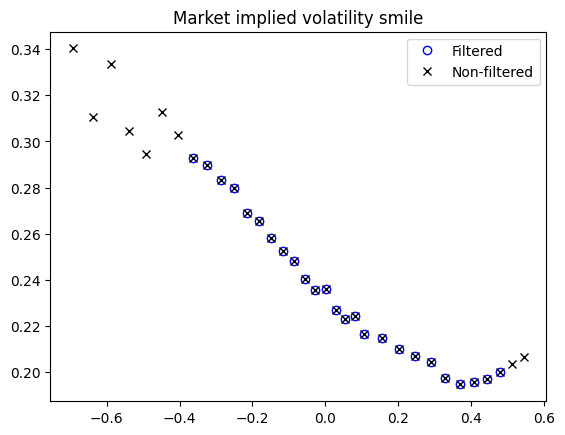

We use the filtered data for calibration only


In [22]:
ListMat = data["Expiration"].unique()
indexMat = -2 ## Select maturity index

df_filt = data[(data["Expiration"] == ListMat[indexMat]) & (data["IV"] >0.) & (data["IV"] <1.) & (data["LogStrike"] < 0.5) & (data["LogStrike"] > -0.4)]
df_nonfilt = data[data["Expiration"] == ListMat[indexMat]]

plt.plot(df_filt["LogStrike"].values, df_filt["IV"].values, "bo", mfc="None", label="Filtered")
plt.plot(df_nonfilt["LogStrike"].values, df_nonfilt["IV"].values, "kx", mfc="None", label="Non-filtered")
plt.title("Market implied volatility smile")
plt.legend(loc="best")
plt.show()
print("We use the filtered data for calibration only")

In [23]:
df_filt.head()

,Expiration,Strike,midPrice,LogStrike,IV
406,1.315068,125.0,58.375,-0.363698,0.292977
407,1.315068,130.0,54.225,-0.324478,0.289935
408,1.315068,135.0,50.025,-0.286737,0.283070
409,1.315068,140.0,46.125,-0.250370,0.279935
410,1.315068,145.0,41.925,-0.215278,0.268997


In [24]:
ivs_market = df_filt["IV"].values
strikes = df_filt["Strike"].values
T = ListMat[indexMat]

### Calibration on Call prices

In [42]:
def lossFunction_prices(params, S0, T, kappa, grid_points, nbPaths, prices_market, dispPrint=False):
    """
    @param = [H, xi0, nu, rho]
    """
    callPrices = rBergomi_callPrices(strikes, grid_points, nbPaths, kappa, S0, T, params)
    normError = np.sum([((a-b)/S0)**2 for (a,b) in zip(callPrices, prices_market)])
    if dispPrint:
        print("L2 Error and parameters: ", np.round(normError, 4), "|", np.round(params, 4))
    return normError

In [43]:
grid_points = 100
nbPaths = 50000
kappa = 2
prices_market = df_filt["midPrice"]
calibBounds = ((0.01,0.49),(0.01,0.2),(0.4,20.),(-0.99,0.1))

H, xi0, nu, rho = 0.1, 0.08, 5.3, -0.9

params = H, xi0, nu, rho
currentLoss = lossFunction_prices(params, S0, T, kappa, grid_points, nbPaths, prices_market, True)

L2 Error and parameters:  0.0667 | [ 0.1   0.08  5.3  -0.9 ]


### Initialisation of the parameters

Randomise the parameters and test a few to find a good initial starting point

In [55]:
calibBounds = ((0.01,0.49),(0.01,0.2),(0.1,4.),(-0.9,0.))

nb_init_test = 25
loss_best = 1E6

for i in range(nb_init_test):
    H = np.random.rand(1)[0]*(calibBounds[0][1] - calibBounds[0][0]) + calibBounds[0][0]
    xi0 = np.random.rand(1)[0]*(calibBounds[1][1] - calibBounds[1][0])  + calibBounds[1][0]
    nu = np.random.rand(1)[0]*(calibBounds[2][1] - calibBounds[2][0])  + calibBounds[2][0]
    rho = np.random.rand(1)[0]*(calibBounds[3][1] - calibBounds[3][0])  + calibBounds[3][0]
    params = H, xi0, nu, rho
    currentLoss = lossFunction_prices(params, S0, T, kappa, grid_points, nbPaths, prices_market)
    #print(currentLoss, "|", params)
    if loss_best > currentLoss:
        p_best = params
        loss_best = currentLoss

print("Best initial set of parameters: ", p_best)

Best initial set of parameters:  (0.21529672979021652, 0.19310506870947508, 1.4382372273920438, -0.5285146832959414)


In [56]:
optim = minimize(lossFunction_prices, p_best, args=(S0, T, kappa, grid_points, nbPaths, prices_market, True), method='SLSQP', bounds=calibBounds, options={'ftolfloat': 1E-6})
optimal_param = optim.x

C:\Users\jack\AppData\Local\Temp\ipykernel_17580\2550891561.py:1: OptimizeWarning: Unknown solver options: ftolfloat
  optim = minimize(lossFunction_prices, p_best, args=(S0, T, kappa, grid_points, nbPaths, prices_market, True), method='SLSQP', bounds=calibBounds, options={'ftolfloat': 1E-6})


L2 Error and parameters:  0.0088 | [ 0.2153  0.1931  1.4382 -0.5285]
L2 Error and parameters:  0.0092 | [ 0.2153  0.1931  1.4382 -0.5285]
L2 Error and parameters:  0.0115 | [ 0.2153  0.1931  1.4382 -0.5285]
L2 Error and parameters:  0.0091 | [ 0.2153  0.1931  1.4382 -0.5285]
L2 Error and parameters:  0.0091 | [ 0.2153  0.1931  1.4382 -0.5285]
L2 Error and parameters:  0.1082 | [ 0.1096  0.2     0.4773 -0.9273]
L2 Error and parameters:  0.0416 | [ 0.1625  0.1966  0.9578 -0.7279]
L2 Error and parameters:  0.0224 | [ 0.1889  0.1948  1.198  -0.6282]
L2 Error and parameters:  0.0147 | [ 0.2021  0.194   1.3181 -0.5784]
L2 Error and parameters:  0.0138 | [ 0.2087  0.1935  1.3782 -0.5534]
L2 Error and parameters:  0.0928 | [ 0.212   0.1933  1.4082 -0.541 ]
L2 Error and parameters:  0.0121 | [ 0.2136  0.1932  1.4232 -0.5347]
L2 Error and parameters:  0.0111 | [ 0.2145  0.1932  1.4307 -0.5316]
L2 Error and parameters:  0.0116 | [ 0.2149  0.1931  1.4345 -0.5301]
L2 Error and parameters:  0.0109 |

In [57]:
print("Initial parameters: ", p_best)
print("Optimal parameters: ", optimal_param)

Initial parameters:  (0.21529672979021652, 0.19310506870947508, 1.4382372273920438, -0.5285146832959414)
Optimal parameters:  [ 0.2152597   0.1931252   1.47214057 -0.52873437]


#### Plot the results

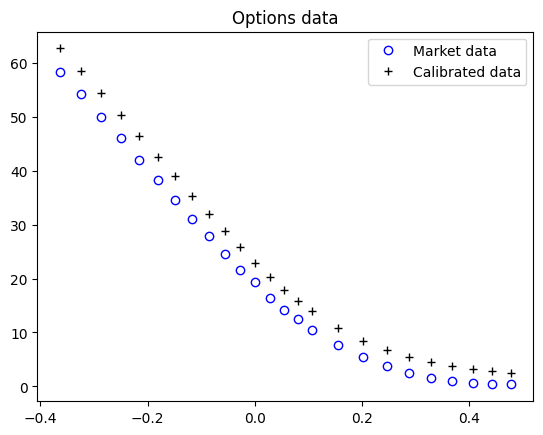

In [58]:
callPrices = rBergomi_callPrices(strikes, grid_points, nbPaths, kappa, S0, T, optimal_param)

plt.plot(df_filt["LogStrike"], prices_market, 'bo', mfc="None", label="Market data")
plt.plot(df_filt["LogStrike"], callPrices, 'k+', label="Calibrated data")
plt.legend(loc="best")
plt.title("Options data")
plt.show()

### Fast calibration on Call prices (assuming H is known)

In [60]:
H = optimal_param[0]
grid_points = 100
nbPaths = 500000

In [61]:
def lossFunction_prices_Fast(params_noH, H, S0, T, kappa, grid_points, nbPaths, prices_market, importedVal, dispPrint=False):
    """
    @paramsnoH = [xi0, nu, rho]
    """
    callPricesFast = rBergomi_callPrices_Fast(strikes, grid_points, nbPaths, kappa, S0, T, params_noH, H, importedVal)
    normError = np.sum([((a-b)/S0)**2 for (a,b) in zip(callPricesFast, prices_market)])
    if dispPrint:
        print(normError, "|", params_noH)
    return normError

In [62]:
importedVal = rBergomi_gen_Matrix(grid_points, nbPaths, kappa, S0, T, H)

### Initialisation of the parameters

Randomise the parameters and test a few to find a good initial starting point

In [64]:
calibBounds_noH = ((0.01,0.2),(0.1,4.),(-0.9,0.))

nb_init_test = 10
loss_init = 1E6

for i in range(nb_init_test):
    xi0 = np.random.rand(1)[0]*(calibBounds_noH[0][1] - calibBounds_noH[0][0])  + calibBounds_noH[0][0]
    nu = np.random.rand(1)[0]*(calibBounds_noH[1][1] - calibBounds_noH[1][0])  + calibBounds_noH[1][0]
    rho = np.random.rand(1)[0]*(calibBounds_noH[2][1] - calibBounds_noH[2][0])  + calibBounds_noH[2][0]
    params_noH = xi0, nu, rho
    currentLoss = lossFunction_prices_Fast(params_noH, H, S0, T, kappa, grid_points, nbPaths, prices_market, importedVal, False)
    print(currentLoss, "|", params_noH)
    if loss_init > currentLoss:
        p_noH_init = params_noH
        loss_init = currentLoss

0.0005318379388823434 | (0.10753532712874793, 1.2047026860511698, -0.7328421383068103)
0.06057187930208604 | (0.022278525686485535, 2.5977267348326474, -0.7021316830590157)
79.37041664463979 | (0.1926058042742961, 1.6254207435032417, -0.3886057916401918)
33202.97011576748 | (0.1829073422612044, 3.772714944449767, -0.7863292073100073)
0.06858126572512208 | (0.010402183968856556, 3.1963627123205756, -0.6114473481432343)
977556.3002634645 | (0.13409015860569526, 3.6947914123528536, -0.8801874545874742)
30.2308062757689 | (0.1917926666856692, 1.4321744489782227, -0.37159574233058545)
0.056881239318263416 | (0.05925296003954006, 3.932653331576336, -0.13218412646550393)
5.535257706318668e+23 | (0.13339121296789438, 2.1620039821080095, -0.03393476174239696)
0.011556726595076332 | (0.16764935186934637, 0.9829420988498936, -0.8381347519672226)


In [65]:
print(loss_init, "|", H, p_noH_init)

0.0005318379388823434 | 0.21525969938577164 (0.10753532712874793, 1.2047026860511698, -0.7328421383068103)


In [66]:
optim = minimize(lossFunction_prices_Fast, p_noH_init, args=(H, S0, T, kappa, grid_points, nbPaths, prices_market, importedVal, True), method='SLSQP', bounds=calibBounds_noH, options={'eps': 1E-3})
optimal_param_noH = optim.x

0.0005318379388823434 | [ 0.10753533  1.20470269 -0.73284214]
0.0004854003206778237 | [ 0.10853533  1.20470269 -0.73284214]
0.0005376594294588865 | [ 0.10753533  1.20570269 -0.73284214]
0.0005249859533897795 | [ 0.10753533  1.20470269 -0.73184214]
0.003241664972479013 | [ 0.15397295  1.1988812  -0.72599015]
0.00028622626710493056 | [ 0.11803583  1.20338633 -0.73129276]
0.00029184192996441444 | [ 0.11903583  1.20338633 -0.73129276]
0.00028613788908754605 | [ 0.11803583  1.20438633 -0.73129276]
0.00028417774326494535 | [ 0.11803583  1.20338633 -0.73029276]
0.0002794278926373674 | [ 0.11669702  1.20299982 -0.7288995 ]
0.00028022005821597633 | [ 0.11769702  1.20299982 -0.7288995 ]
0.00027993888773081673 | [ 0.11669702  1.20399982 -0.7288995 ]
0.0002769346127024156 | [ 0.11669702  1.20299982 -0.7278995 ]
0.00026534538807078016 | [ 0.11413518  1.20117349 -0.71982211]
0.0002592490716017768 | [ 0.11513518  1.20117349 -0.71982211]
0.00026667639445675825 | [ 0.11413518  1.20217349 -0.71982211]
0

In [67]:
print("Initial parameters: ", p_noH_init)
print("Optimal parameters: ", optimal_param_noH)

Initial parameters:  (0.10753532712874793, 1.2047026860511698, -0.7328421383068103)
Optimal parameters:  [ 0.09824598  1.16561578 -0.56294491]


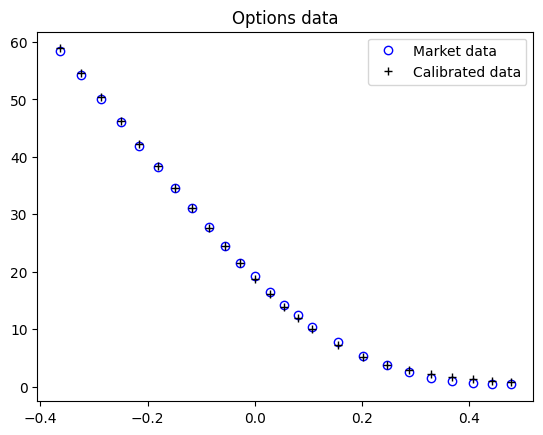

In [68]:
(volpathFast,stockpathFast) = rBergomi_hybrid_Fast(grid_points, nbPaths, kappa, S0, T, optimal_param_noH, H, importedVal)
Call_pricesFast = compute_CallPrices_from_ST(strikes, stockpathFast)

plt.plot(df_filt["LogStrike"], prices_market, 'bo', mfc="None", label="Market data")
plt.plot(df_filt["LogStrike"], Call_pricesFast, 'k+', label="Calibrated data")
plt.legend(loc="best")
plt.title("Options data")
plt.show()